In [30]:
import json
import networkx as nx
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from networkx.readwrite import json_graph

In [31]:
df = pd.read_csv("cluster_metrics.csv")
df["amplitude"] = df["cluster_mean_node_rho"] - df["city_mean_node_rho"]

In [32]:
CBSA_CONFIG = {1714000: "Chicago", 4260000: "Philadelphia"}


In [33]:
df["area_code"].map(CBSA_CONFIG)

0          Chicago
1          Chicago
2          Chicago
3          Chicago
4          Chicago
5          Chicago
6          Chicago
7          Chicago
8          Chicago
9          Chicago
10    Philadelphia
11    Philadelphia
12    Philadelphia
13    Philadelphia
14    Philadelphia
15    Philadelphia
16    Philadelphia
17    Philadelphia
18    Philadelphia
19    Philadelphia
Name: area_code, dtype: object

In [34]:
df

,area_code,year,cluster,tract_count,component_count,area_black_population,area_total_population,area_black_share,cluster_rho,city_rho,city_mean_node_rho,cluster_mean_node_rho,dropoff,spread,center_node_id,center_gisjoin,center_geoid,amplitude
0,1714000,1980,cluster_1,261,1,804171,1000434,0.803822,0.858968,0.477589,0.427993,0.828301,3.663782,5.796661,263,G17003106911,17003106911,0.400308
1,1714000,1990,cluster_1,261,1,705349,854000,0.825936,0.897376,0.504335,0.475119,0.884139,2.115047,5.854580,801,G17003106912,17003106912,0.409020
2,1714000,2000,cluster_1,261,1,679640,810676,0.838362,0.947823,0.537452,0.500982,0.927674,-2.421725,5.851766,191,G17031691200,17031691200,0.426691
3,1714000,2010,cluster_1,234,1,553104,676265,0.817881,0.959464,0.509665,0.469625,0.940366,-5.221829,5.321146,492,G17031691200,17031691200,0.470741
4,1714000,2020,cluster_1,230,1,495148,650816,0.760811,0.957900,0.482006,0.462259,0.938609,-4.457447,5.300607,326,G17031691200,17031691200,0.476350
5,1714000,1980,cluster_2,120,1,291272,383837,0.758843,0.878354,0.477589,0.427993,0.848991,-2.299583,4.456086,281,G17003102315,17003102315,0.420998
6,1714000,1990,cluster_2,120,1,252030,313405,0.804167,0.948076,0.504335,0.475119,0.932939,-4.000351,4.695199,137,G17003102908,17003102908,0.457820
7,1714000,2000,cluster_2,121,1,236343,300487,0.786533,0.968099,0.537452,0.500982,0.936102,-3.139951,4.171717,388,G17031260400,17031260400,0.435119
8,1714000,2010,cluster_2,86,1,187842,253693,0.740430,0.953915,0.509665,0.469625,0.926886,-3.336084,3.198529,45,G17031831400,17031831400,0.457261
9,1714000,2020,cluster_2,85,1,160889,248563,0.647277,0.934646,0.482006,0.462259,0.898843,-3.432109,3.104233,74,G17031831400,17031831400,0.436584


In [35]:
groups = {key: group for key, group in df.groupby(["area_code", "cluster"])}
CBSA_CONFIG = {1714000: "Chicago", 4260000: "Philadelphia"}
groups = {key: group for key, group in df[df["area_code"].isin(CBSA_CONFIG)].groupby(["area_code", "cluster"])}

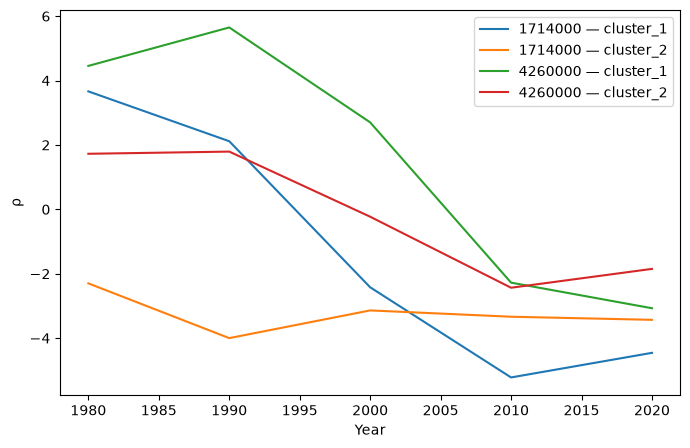

In [36]:
fig, ax = plt.subplots(figsize=(8, 5))

for (area_code, cluster), group in groups.items():
    g = group.sort_values("year")
    ax.plot(g["year"], g["dropoff"], label=f"{area_code} — {cluster}")

ax.set_xlabel("Year")
ax.set_ylabel("ρ")
ax.legend()
plt.show()